## Decision Tree

## Tiatnic Survival Dataset

In [3]:
#Import the Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score

In [4]:
#Load the data sets- train and test 

df = pd.read_csv("train.csv")

In [5]:
#Look at top values of train data 

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#Print the column names of train data

print("Column names of data : " , df.columns.to_list())

Column names of data :  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [7]:
#Print the dimension of train and test data

print(f"Dimension of data : {df.shape} ")

Dimension of data : (891, 12) 


In [13]:
#Print the number of missing values in each column of train and test data

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Visualization

    countplot() → Directly counts occurrences of categories (X: category, Y: count).
    barplot() → Requires manual aggregation (X: category, Y: any numerical value like count, mean, sum, etc.).

Use countplot() for quick counts, barplot() for more control.

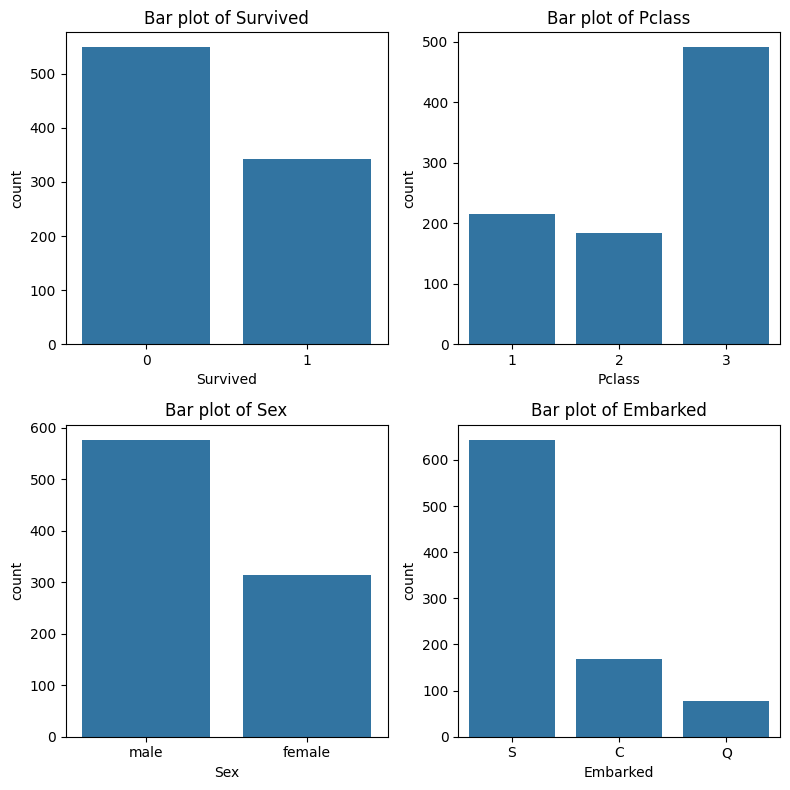

In [16]:
#Barchart of Survived, Pclass, Sex, Embarked

cols = ["Survived", "Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(2, 2, figsize=(8,8))
axes = axes.flatten()

for i,col in enumerate(cols):
    cur_ax = axes[i]
    sns.countplot(data=df,x=col, ax=cur_ax)
    cur_ax.set_title(f"Bar plot of {col}")

plt.tight_layout()
plt.show()
    

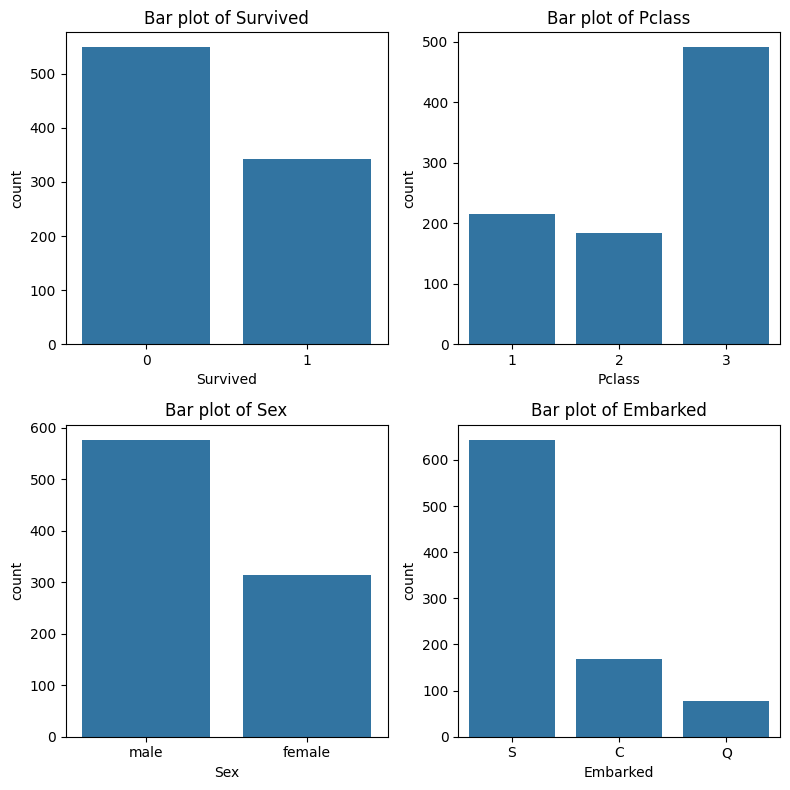

In [17]:
# using same bar plot instead of count plot

fig, axes = plt.subplots(2,2,figsize=(8,8))
axes = axes.flatten()

for i,col in enumerate(cols):
    cur_ax = axes[i]
    new_count_df = df[col].value_counts().reset_index()
    sns.barplot(data=new_count_df,x=col,y="count",ax = cur_ax)
    cur_ax.set_title(f"Bar plot of {col}")

plt.tight_layout()
plt.show()
    

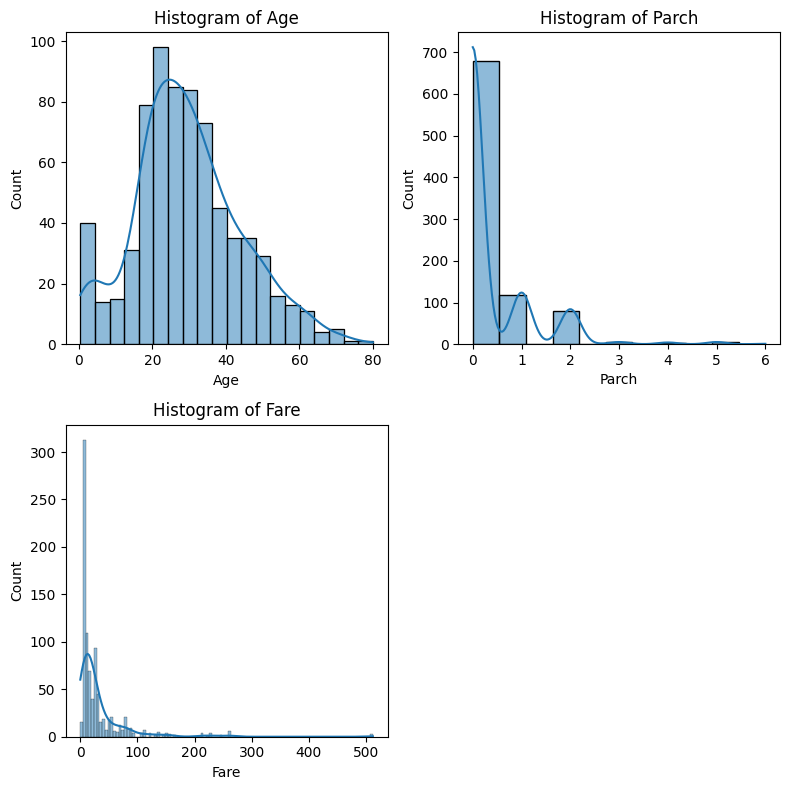

In [23]:
#Histogram of Age, Parch, Fare


cols = ["Age", "Parch", "Fare"]

fig, axes = plt.subplots(2,2,figsize=(8,8))
axes = axes.flatten()

for i, col in enumerate(cols):
    cur_ax = axes[i]
    sns.histplot(df[col],kde=True,ax = cur_ax)
    cur_ax.set_title(f"Histogram of {col}")

plt.delaxes(axes[-1])
plt.tight_layout()
plt.show()

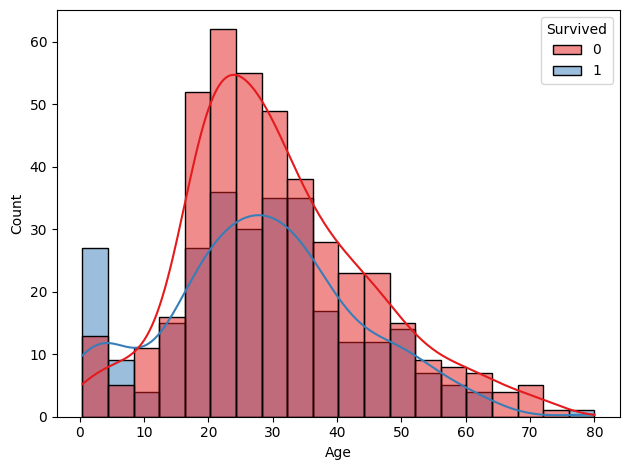

In [24]:
#Plot histogram of age for survived and did not survived class

sns.histplot(data=df,x="Age",kde=True,palette="Set1",hue="Survived")
plt.tight_layout()
plt.show()

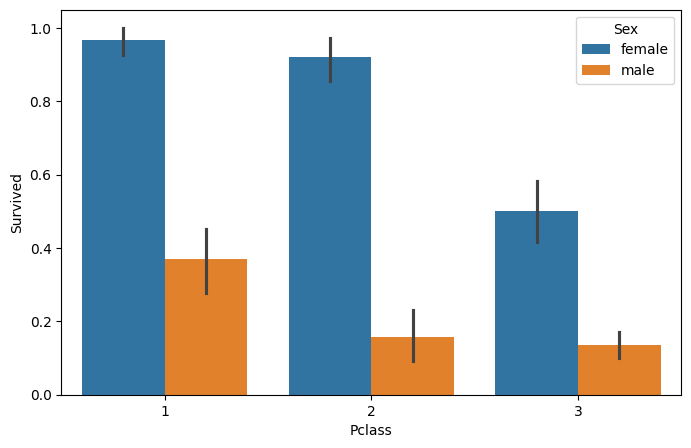

In [18]:
#Count class and gender wise survival rate - plot with appropriate chart

plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Pclass",y="Survived",hue="Sex")
plt.show()

/tmp/ipykernel_9034/639291750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x="Age",hue="Sex",shade=True,palette="Set2",common_norm=False)


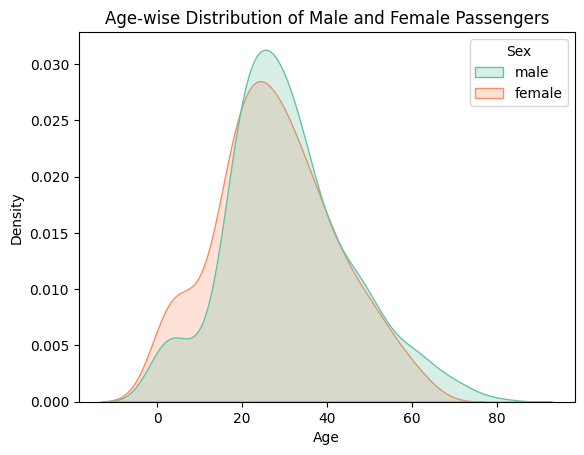

In [19]:
#Age wise Distribution of Male and Female passengers


# one way using: KDE plot

sns.kdeplot(data=df,x="Age",hue="Sex",shade=True,palette="Set2",common_norm=False)
plt.title("Age-wise Distribution of Male and Female Passengers")
plt.show()

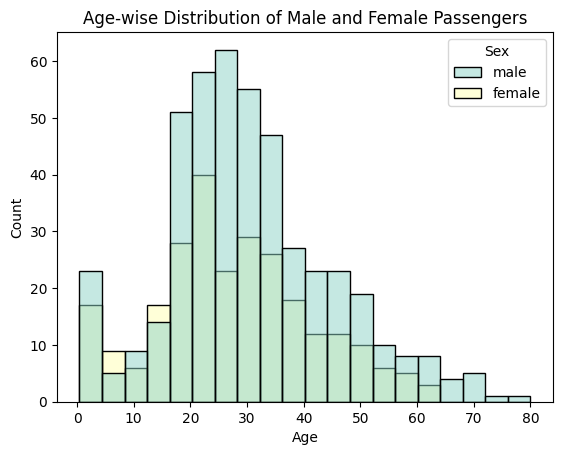

In [25]:
#Age wise Distribution of Male and Female passengers



# another way using : Histogram plot


sns.histplot(data=df,x="Age",hue="Sex",palette="Set3")
plt.title("Age-wise Distribution of Male and Female Passengers")
plt.show()


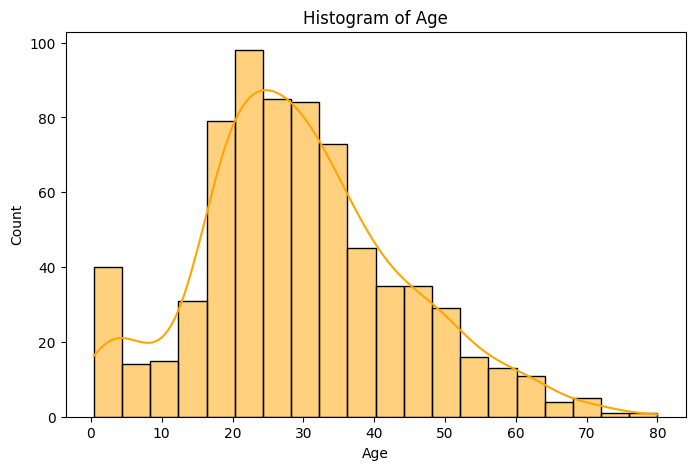

In [20]:
#Histogram of Age of the given data set(sample)

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Age",kde=True,color="orange")
plt.title("Histogram of Age")
plt.show()

## Handling Missing Values

In [26]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
#Replace the msiing values in Embarked column by 'S'

df["Embarked"].fillna("S",inplace=True)


In [31]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
#Impute the missing values in Fare column with median value


df["Fare"].fillna(df["Fare"].median(),inplace=True)

/tmp/ipykernel_9034/1014571406.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fare"].fillna(df["Fare"].median(),inplace=True)


In [33]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [34]:
#Impute the Age column. It has too many missing values but it may be important. 
#We fill the missing values with numbers randomly drawn from distribution
#that has same mean and standard deviation as non missing Age data

mean_age = df["Age"].mean()
std_age = df["Age"].std()

print(mean_age, std_age)

# x is the each value in Age col
def fill_missing(x):
    if pd.isnull(x):
        # at generates random numbers drawn from a normal (Gaussian) distribution 
        return np.random.normal(mean_age,std_age)
    return x

df["Age"] = df["Age"].apply(fill_missing)

mean_age = df["Age"].mean()
std_age = df["Age"].std()

print(mean_age, std_age)


29.69911764705882 14.526497332334042
29.639816990152195 14.208471990260051


## Feature Engineering - Creating new features

In [35]:
# Create and add a new feature FamilySize as a combination of SibSp and Parch
#FamilySize = Parch + SibSp + 1

df["FamilySize"] = df["Parch"] + df["SibSp"] + 1

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [ ]:
# Create new feature IsAlone from FamilySize
#If FamilySize == 1 then IsAlone = True else IsAlone = False

df["IsAlone"] = df["FamilySize"] == 1

df.head()

## Create a new attribute Has_cabin using the attribue Cabin. 



In [36]:
#if Cabin == NaN the Has_cabin = False else Has_cabin = True

df["Has_cabin"] = df["Cabin"].notna()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,False


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  Has_cabin    891 non-null    bool   
dtypes: bool(1), float64(2), int64(6), object(5)
memory usage: 91.5+ KB


In [38]:

#Drop the columns which may not be useful in prediction of survival
#Drop PassengerId, Name, Ticket, and Cabin

df.drop(columns=["Name", "PassengerId","Ticket","Cabin"],inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Has_cabin
0,0,3,male,22.0,1,0,7.2500,S,2,False
1,1,1,female,38.0,1,0,71.2833,C,2,True
2,1,3,female,26.0,0,0,7.9250,S,1,False
3,1,1,female,35.0,1,0,53.1000,S,2,True
4,0,3,male,35.0,0,0,8.0500,S,1,False


## Model Building

In [39]:
#Prepare X and y

x = df.drop(columns="Survived")
y = df["Survived"]

x.head(), y.head()

(   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  Has_cabin
 0       3    male  22.0      1      0   7.2500        S           2      False
 1       1  female  38.0      1      0  71.2833        C           2       True
 2       3  female  26.0      0      0   7.9250        S           1      False
 3       1  female  35.0      1      0  53.1000        S           2       True
 4       3    male  35.0      0      0   8.0500        S           1      False,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [40]:
# Label encoding of categorical features

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    encoder = LabelEncoder()
    x[col] = encoder.fit_transform(df[col])

In [41]:
# concat df_categorical with original df


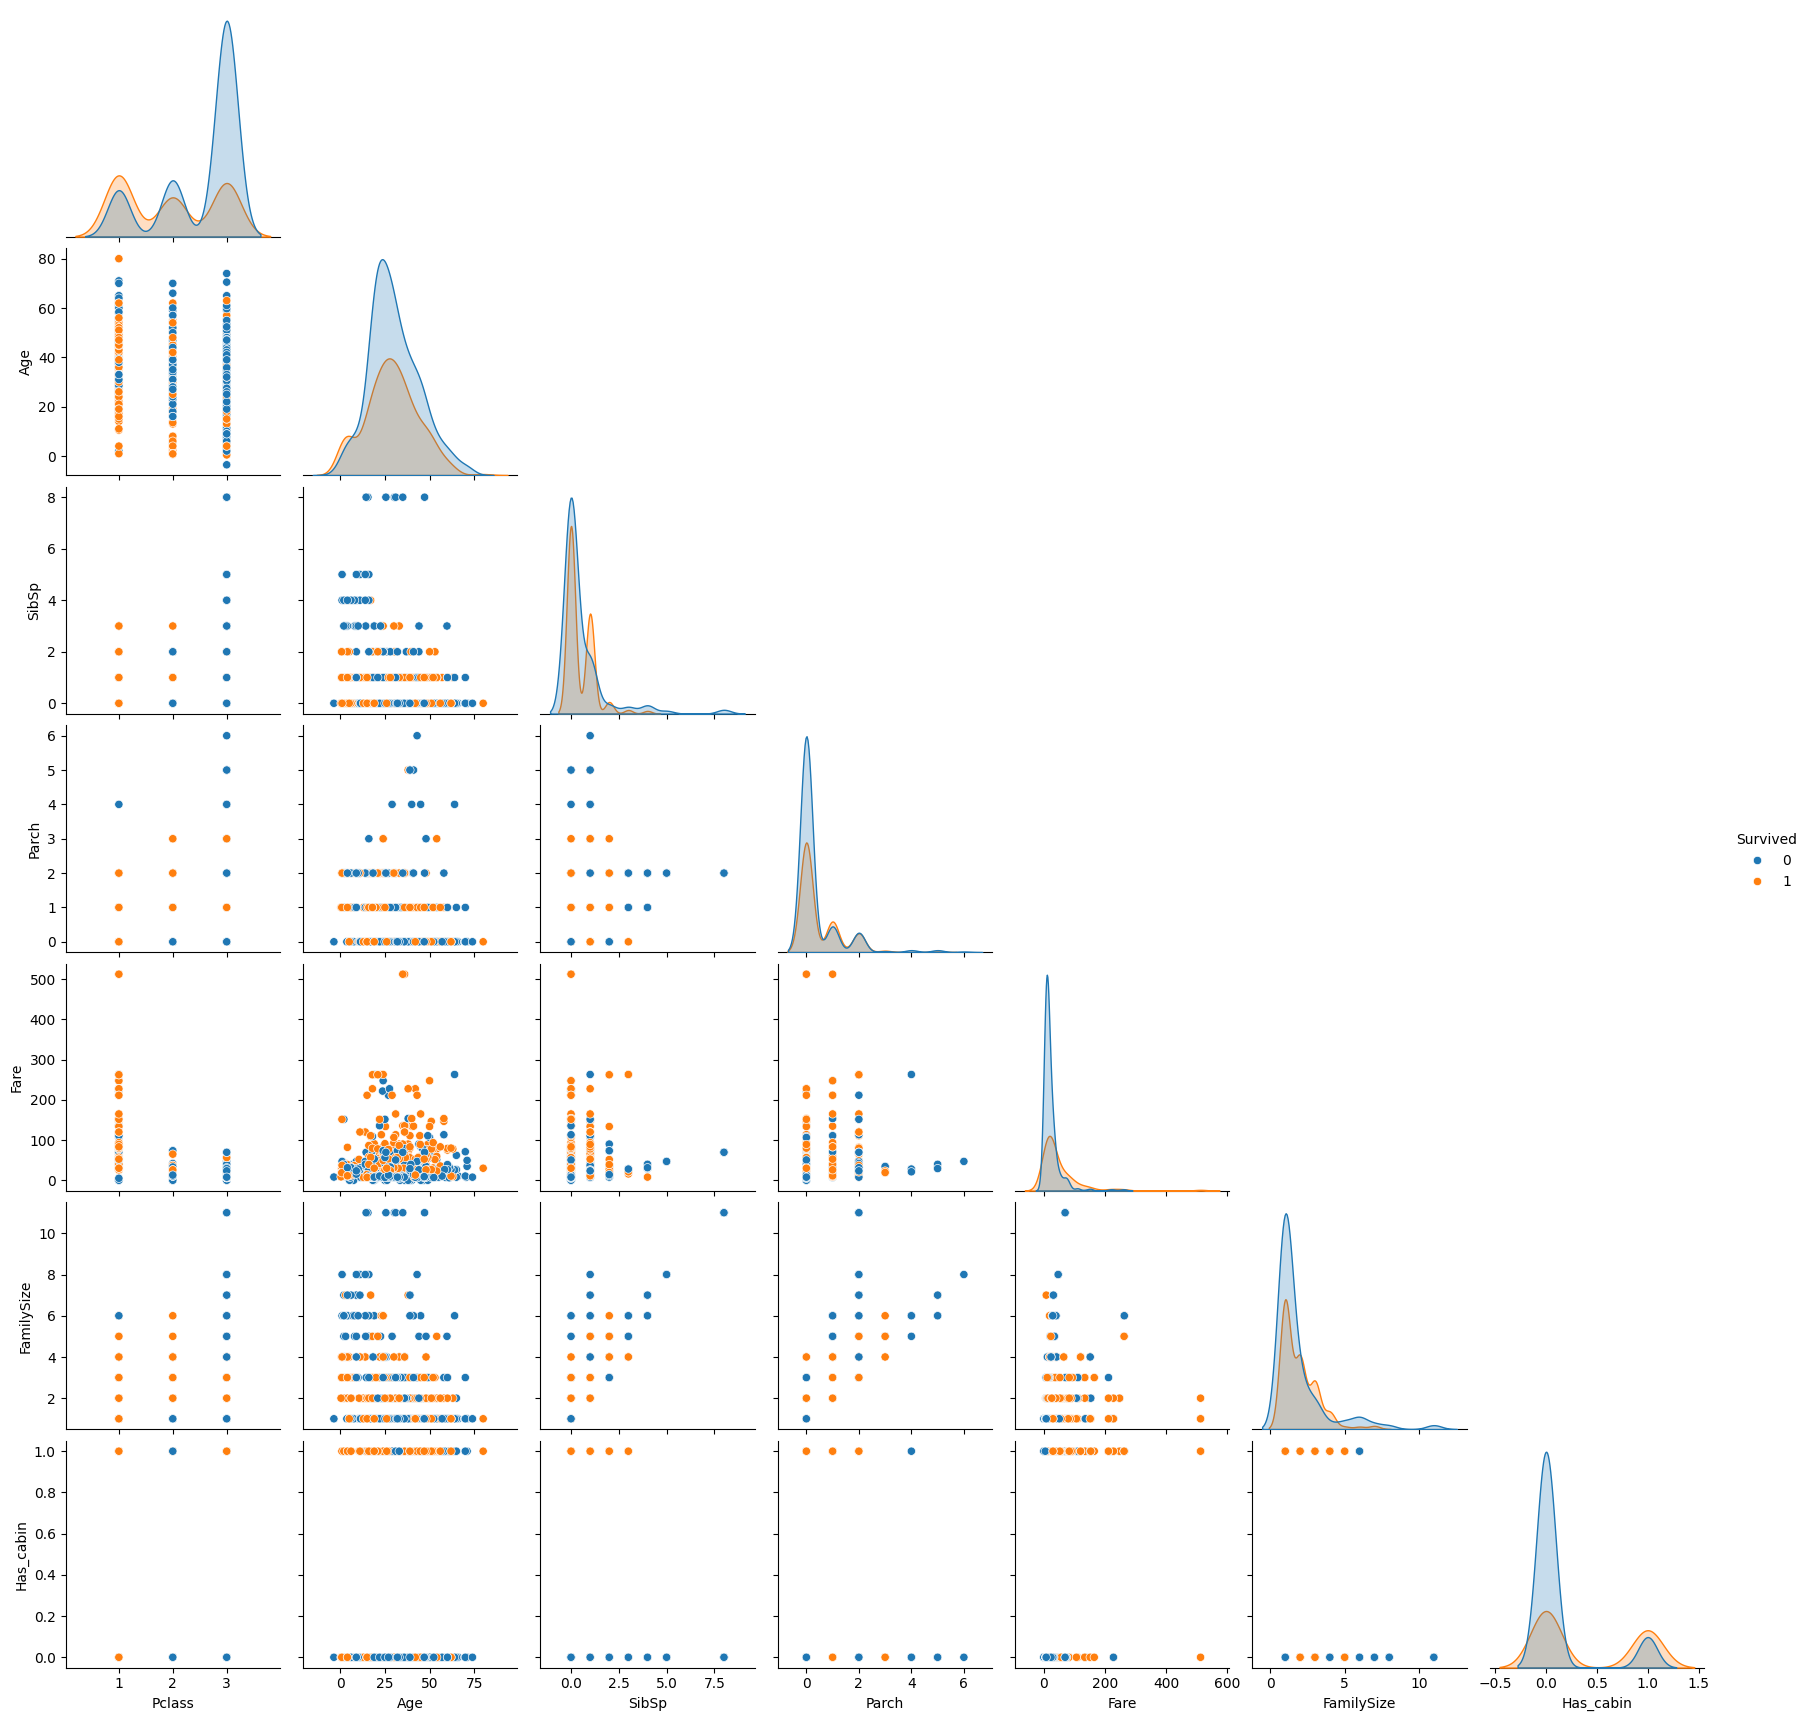

In [43]:
#Do a pairplot of all features


sns.pairplot(df,corner=True,hue="Survived")
plt.show()

In [44]:
# Splitting the data into train and validation set - 90% train 10% validation
#X_train, X_test, y_train, y_validation

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1,random_state=42)

x_train.shape, x_test.shape

((801, 9), (90, 9))

In [ ]:
x.head()

In [47]:
# Create the model
# Fitting the decision tree with default hyperparameters
# Importing decision tree classifier from sklearn library

model = DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

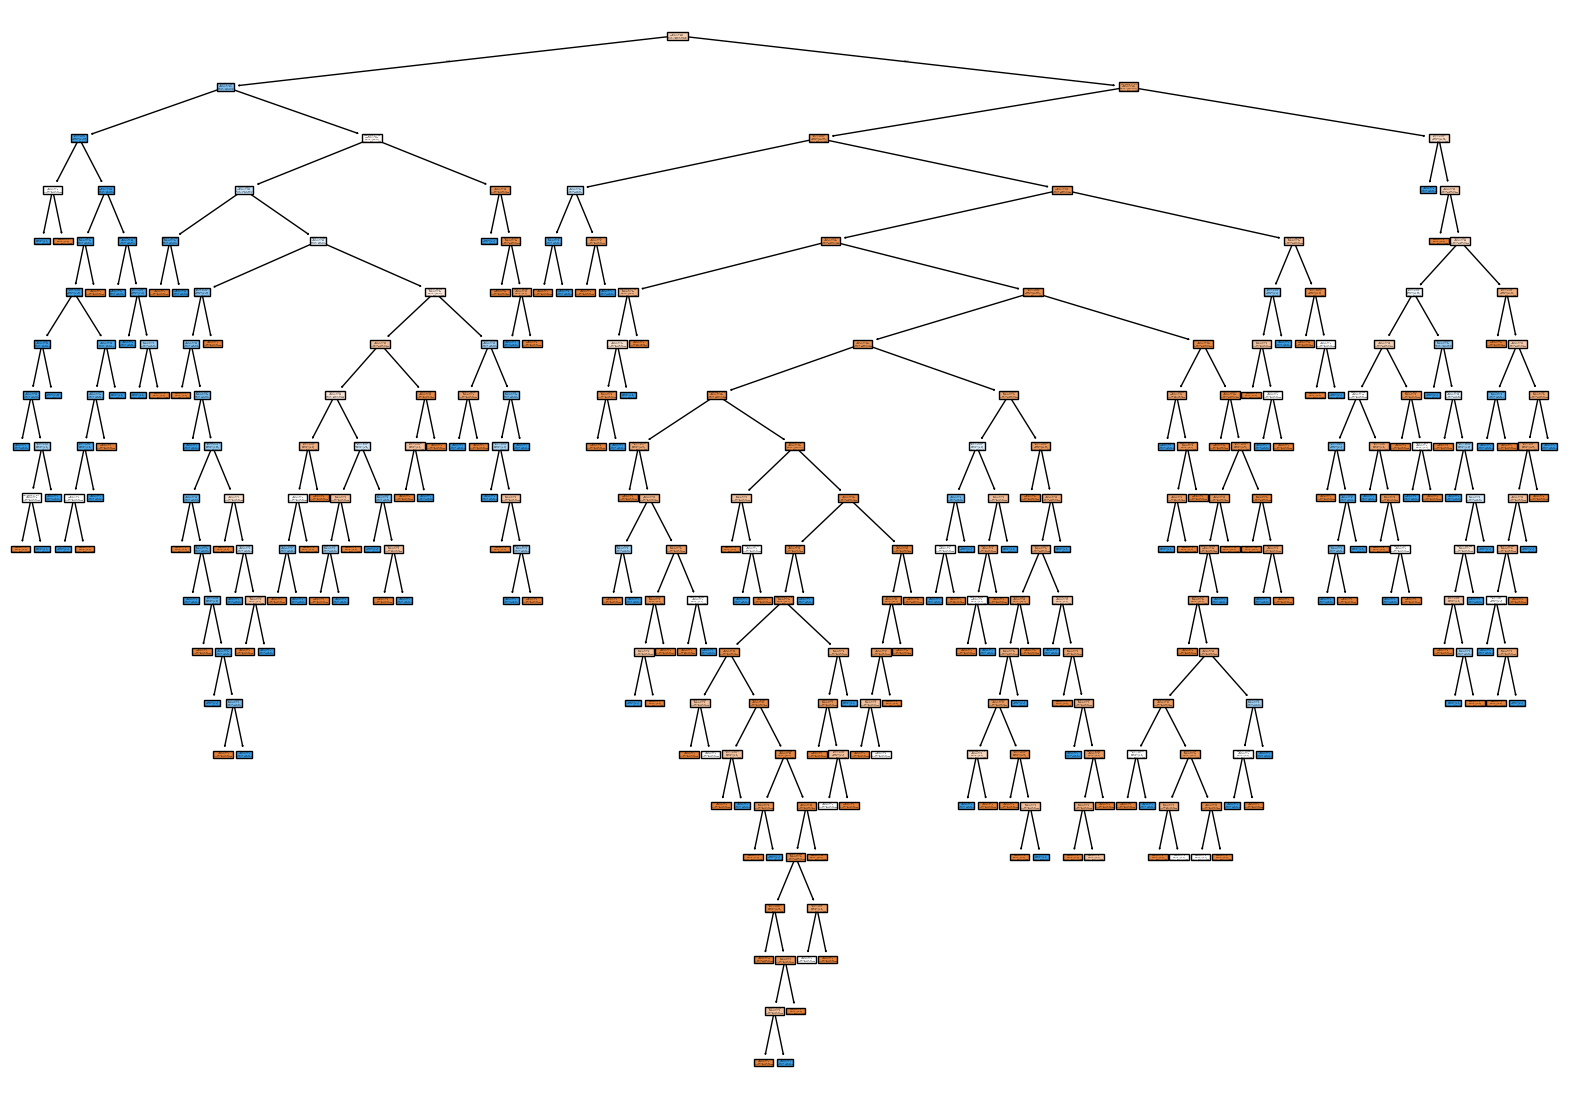

In [48]:
#Print the tree

# Importing required packages for visualization

plt.figure(figsize=(20,14))
plot_tree(model,feature_names=x.columns,class_names=["Not Survived","Survived"],filled=True)
plt.show()

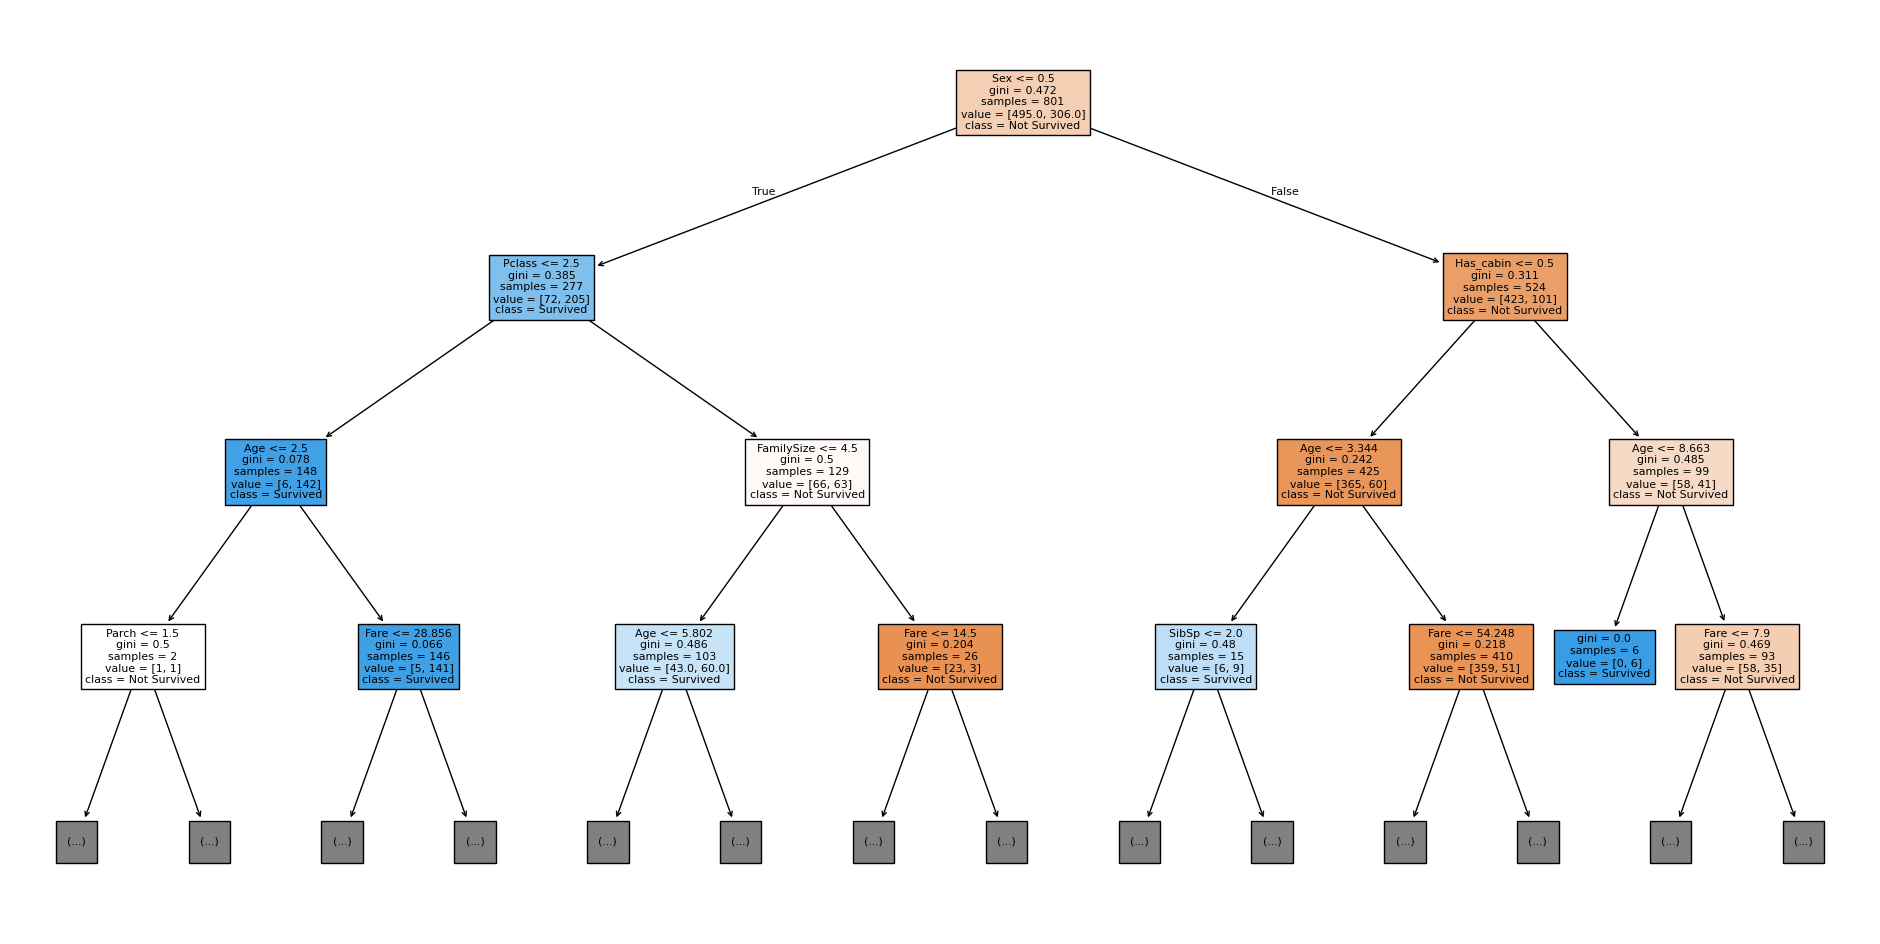

In [49]:
# plotting tree with max_depth=3

plt.figure(figsize=(24,12))
plot_tree(model,feature_names=x.columns,class_names=["Not Survived", "Survived"],filled=True,max_depth=3)
plt.show()

In [54]:
# Check the evaluation metrics of our default model on validation set - Confusion Matrix, Accuracy, Precision, Recall, F1 score

# Importing classification report and confusion matrix from sklearn metrics

# Making predictions

# Printing classification report

y_pred = model.predict(x_test)


print(f"Precision score : {precision_score(y_test,y_pred):.2f}")
print(f"Recall score: {recall_score(y_test,y_pred):.2f}")
print(f"F1 score :  {f1_score(y_test,y_pred):.2f}")
print("\nClassification Report : \n",classification_report(y_test,y_pred) )


Precision score : 0.74
Recall score: 0.86
F1 score :  0.79

Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.80      0.84        54
           1       0.74      0.86      0.79        36

    accuracy                           0.82        90
   macro avg       0.82      0.83      0.82        90
weighted avg       0.83      0.82      0.82        90



In [55]:
# Printing confusion matrix and accuracy

print("Cofusion matrix : \n",confusion_matrix(y_test,y_pred))
print(f"\nAccuracy score : {accuracy_score(y_test,y_pred):.2f}")

Cofusion matrix : 
 [[43 11]
 [ 5 31]]

Accuracy score : 0.82


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 14. Load the dataset
try:
    mpg_df = pd.read_csv('set_1_dataset_2.csv')
    print("\nAutomobile MPG dataset loaded successfully!")
except FileNotFoundError:
    print("Error: set_1_dataset_2.csv not found. Please make sure the file is in the correct directory.")
    exit()

# 15. Print the data types of each column
print("\nData types of each column:")
print(mpg_df.dtypes)

# 16. Print the number of missing values in each column
print("\nNumber of missing values in each column:")
print(mpg_df.isnull().sum())

# 17. Drop rows with missing output labels (mpg column)
mpg_df_cleaned = mpg_df.dropna(subset=['mpg'])
print("\nShape of dataset after dropping rows with missing mpg:", mpg_df_cleaned.shape)

# 18. Impute the missing values if any (mean/mode)
# Identify numerical and categorical columns
numerical_cols = mpg_df_cleaned.select_dtypes(include=np.number).columns.tolist()
categorical_cols = mpg_df_cleaned.select_dtypes(include='object').columns.tolist()

# Remove the target variable from numerical columns
if 'mpg' in numerical_cols:
    numerical_cols.remove('mpg')

# Create transformers for imputation and encoding
numerical_transformer = SimpleImputer(strategy='mean')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'  # Keep other columns (if any)
)

# Fit and transform the data
preprocessor.fit(mpg_df_cleaned)
mpg_processed = preprocessor.transform(mpg_df_cleaned)

# Get the feature names after preprocessing (for better understanding)
feature_names = preprocessor.get_feature_names_out(numerical_cols + categorical_cols)
mpg_processed_df = pd.DataFrame(mpg_processed, columns=feature_names)

print("\nMissing values after imputation:")
print(mpg_processed_df.isnull().sum())
print("\nProcessed data shape:", mpg_processed_df.shape)

# Prepare features (X) and label (y) after imputation and encoding
X = mpg_processed_df.values
y = mpg_df_cleaned['mpg'].values

# 22. Prepare features (X) and label (y), split the dataset (15% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print("\nShape of training features:", X_train.shape)
print("Shape of training label:", y_train.shape)
print("Shape of testing features:", X_test.shape)
print("Shape of testing label:", y_test.shape)

# 20. Plot a histogram of the horsepower column
plt.figure()
plt.hist(mpg_df_cleaned['horsepower'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.title('Histogram of Horsepower')
plt.show()

# 21. Plot a scatter plot of weight and horsepower vs mpg in two subplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mpg_df_cleaned['weight'], mpg_df_cleaned['mpg'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Weight vs MPG')

plt.subplot(1, 2, 2)
plt.scatter(mpg_df_cleaned['horsepower'], mpg_df_cleaned['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')

plt.tight_layout()
plt.show()

# 23. Train a regression model
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
print("\nRegression model trained!")

# 24. Print the R² value on the test data
y_pred_reg = regression_model.predict(X_test)
r2 = r2_score(y_test, y_pred_reg)
print("\nR² value on the test data:", r2)

# 25. Predict the regression coefficients
coefficients = regression_model.coef_
print("\nRegression Coefficients:")
print(coefficients)

Error: set_1_dataset_2.csv not found. Please make sure the file is in the correct directory.

Data types of each column:


NameError: name 'mpg_df' is not defined